# Maximum Independent Set

The explicit Hamiltonian used for Maximum Independent Set (binary variables $x_i\in\{0,1\}$, $x_i=1$ means “select node i”) is : 

$H(\mathbf{x}) \;=\; A\sum_{(i,j)\in E} x_i x_j \;-\; B\sum_{i\in V} x_i$. 

1. $A\sum_{(i,j)\in E} x_i x_j$: penalty for selecting adjacent nodes (any edge with both endpoints selected adds energy). 
2. $-B\sum_i x_i$: reward for selecting more nodes (since we minimize H, this pushes size up). 
3. Choose $A \gg B$ to enforce independence strongly.

In the mean-field (what the FEM code optimizes), the expectation becomes:
$U(\mathbf{p}) \;=\; A\sum_{(i,j)\in E} p_i p_j \;-\; B\sum_i p_i$ (where U is the internal energy)
with the undirected double-counting handled via $a /2$ when using the symmetric adjacency matrix form.

Solved using sequential greedy algorithm. FEM learns a soft ranking over vertices; the final MIS is extracted by a sequential greedy pass using that ranking.

In [38]:
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# GRAPH UTILITIES
def random_binary_undirected_graph(n_nodes=15, edge_prob=0.07, seed=1, directed=False):
    return nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=directed)
def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)
    np.fill_diagonal(W, 0.0)
    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0
    return W
def draw_graph(G, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=True, node_color="lightblue")
    plt.show()

# MIS plotting
def draw_graph_with_mis(G, x, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    node_colors = ["tab:orange" if x[i] == 1 else "tab:blue" for i in G.nodes()]
    edge_colors = []
    for u, v in G.edges():
        edge_colors.append("red" if (x[u] == 1 and x[v] == 1) else "lightgray")
    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors)
    plt.show()

In [40]:
def S_bernoulli(p, eps=1e-12):
    p = p.clamp(eps, 1 - eps)
    return -(p * p.log() + (1 - p) * (1 - p).log()).sum(1)
def mis_energy(W, p, A=10.0, B=1.0): 
    # As per hamiltonian definition
    return A * (((p @ W) * p).sum(1) / 2.0) - B * p.sum(1)

# Constraint repair heuristic and violation counting
def greedy_repair_mis_from_probs(G, p_vec):
    order = np.argsort(-p_vec)  # descending p
    blocked = set()
    x = np.zeros(len(p_vec), dtype=np.int32)

    for i in order:
        if i in blocked:
            continue
        x[i] = 1
        blocked.add(i)
        for nb in G.neighbors(i):
            blocked.add(nb)
    return x
def count_violations(W_np, x):
    x = x.astype(np.float32)
    return float(((x @ W_np) * x).sum() / 2.0)

In [41]:
def solve_mis(G, W_np_or_torch, batch=64, lr=0.05, steps=400, A=10.0, B=1.0, beta_min=0.5, beta_max=20.0):
    device = "mps" if torch.backends.mps.is_available() else "cpu"

    W = W_np_or_torch
    if not torch.is_tensor(W):
        W = torch.tensor(W, dtype=torch.float32)
    W = W.to(device)

    n = W.shape[0]
    h = torch.nn.Parameter(torch.zeros(batch, n, device=device))
    opt = torch.optim.Adam([h], lr=lr)
    beta_range = torch.linspace(beta_min, beta_max, steps=steps).to(device)

    for beta in beta_range:
        p = torch.sigmoid(h)
        Fval = mis_energy(W, p, A=A, B=B) - S_bernoulli(p) / beta
        opt.zero_grad()
        Fval.sum().backward()
        opt.step()

    p_all = torch.sigmoid(h).detach().cpu().numpy()   # (batch, n)
    h_all = h.detach().cpu().numpy()                  # (batch, n)

    best_x = None
    best_p = None
    best_h = None
    best_size = -1

    for r in range(batch):
        x_r = greedy_repair_mis_from_probs(G, p_all[r])
        size_r = int(x_r.sum())
        if size_r > best_size:
            best_size = size_r
            best_x = x_r
            best_p = p_all[r]
            best_h = h_all[r]

    return {
        "x_best": best_x,        # binary MIS solution
        "p_best": best_p,        # marginals
        "h_best": best_h,        # logits
        "best_size": best_size
    }

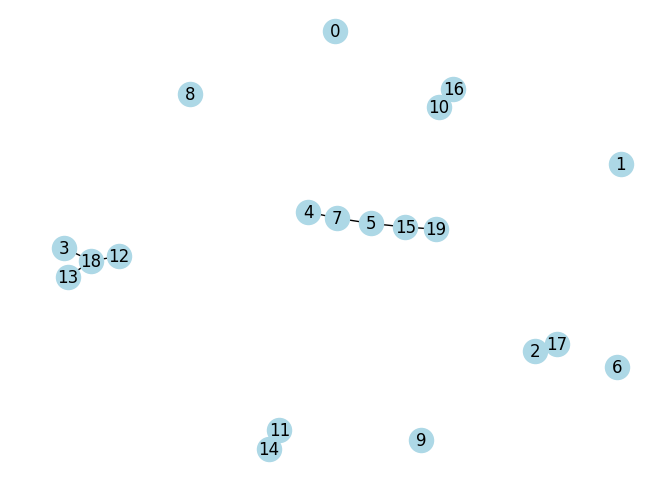

W shape: (20, 20)
Unique values in W: [0. 1.]
Best MIS size: 14
Best logits: [ 5.429216   5.429216  -2.0796924  3.8472085  3.759257   1.7705575
  5.429216  -5.8380623  5.429216   5.429216  -2.0796924 -2.0796924
  3.8472085  3.8472085 -2.0796924 -5.8380623 -2.0796924 -2.0796924
 -6.1996307  3.759257 ]
Best marginals: [0.9956326  0.9956326  0.11108633 0.97910666 0.9772296  0.854527
 0.9956326  0.00290601 0.9956326  0.9956326  0.11108633 0.11108633
 0.97910666 0.97910666 0.11108633 0.00290601 0.11108633 0.11108633
 0.00202607 0.9772296 ]
Best x: [1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1]


In [42]:
# Parameters
n_nodes   = 20
edge_prob = 0.07
seed      = 14

# hyperparameters
batch     = 64
steps     = 400
lr        = 0.05
beta_min  = 0.5
beta_max  = 20.0
A         = 10.0
B         = 1.0

G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
W = graph_to_binary_adjacency(G)
draw_graph(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

out = solve_mis(G, W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)
best_size, h_best, p_best, x_best = out["best_size"], out["h_best"], out["p_best"], out["x_best"]

print("Best MIS size:", best_size)
print("Best logits:", h_best)
print("Best marginals:", p_best)
print("Best x:", x_best)

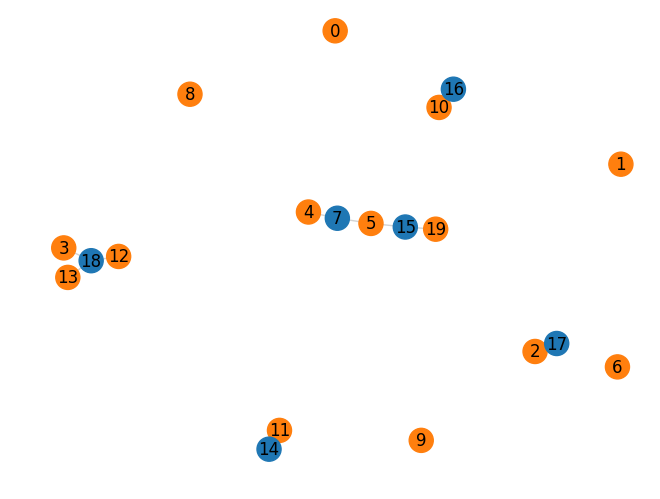

,logit,marginal_p(x=1),independent_set_member
0,5.429216,0.995633,Independent
1,5.429216,0.995633,Independent
2,-2.079692,0.111086,Independent
3,3.847208,0.979107,Independent
4,3.759257,0.977230,Independent
5,1.770558,0.854527,Independent
6,5.429216,0.995633,Independent
7,-5.838062,0.002906,Not Independent
8,5.429216,0.995633,Independent
9,5.429216,0.995633,Independent


In [43]:
import pandas as pd
def mis_marginals_dataframe(h_best, p_best):
    n = len(h_best)
    df = pd.DataFrame({
        "logit": h_best,
        "marginal_p(x=1)": p_best,
        "independent_set_member": ["Independent" if x == 1 else "Not Independent" for x in x_best]
    })
    return df

df_mis = mis_marginals_dataframe(h_best, p_best)
draw_graph_with_mis(G, x_best)
df_mis

Example 2

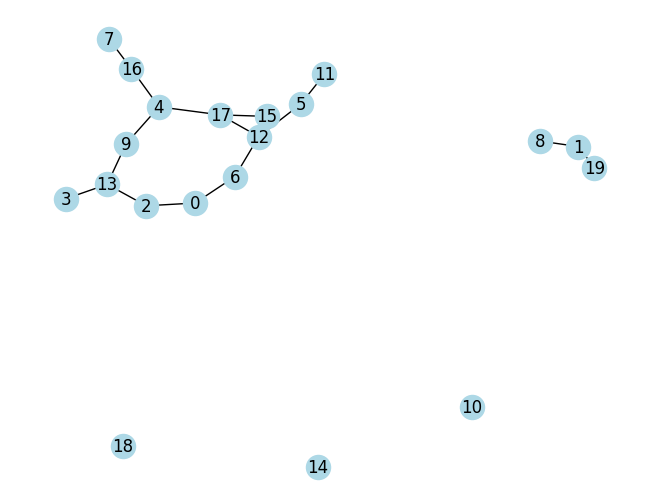

W shape: (20, 20)
Unique values in W: [0. 1.]
Best MIS size: 12
Best logits: [-3.8468919  -6.2272606  -0.21565138  3.7407105  -3.2493145  -5.5310388
 -2.4031618   3.737771    3.8317442  -0.5078567   5.429216    3.738569
 -2.4667733  -5.3713884   5.429216    3.715601   -5.5151644  -5.1643224
  5.429216    3.8317442 ]
Best marginals: [0.02089985 0.00197096 0.44629514 0.9768132  0.03735153 0.00394624
 0.08293191 0.97674644 0.97878796 0.37569606 0.9956326  0.9767646
 0.07822057 0.00462617 0.9956326  0.97623754 0.00400913 0.00568444
 0.9956326  0.97878796]
Best x: [0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 0 1 1]


In [45]:
n_nodes   = 20
edge_prob = 0.09
seed      = 15

G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
W = graph_to_binary_adjacency(G)
draw_graph(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

out = solve_mis(G, W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)
best_size, h_best, p_best, x_best = out["best_size"], out["h_best"], out["p_best"], out["x_best"]

print("Best MIS size:", best_size)
print("Best logits:", h_best)
print("Best marginals:", p_best)
print("Best x:", x_best)

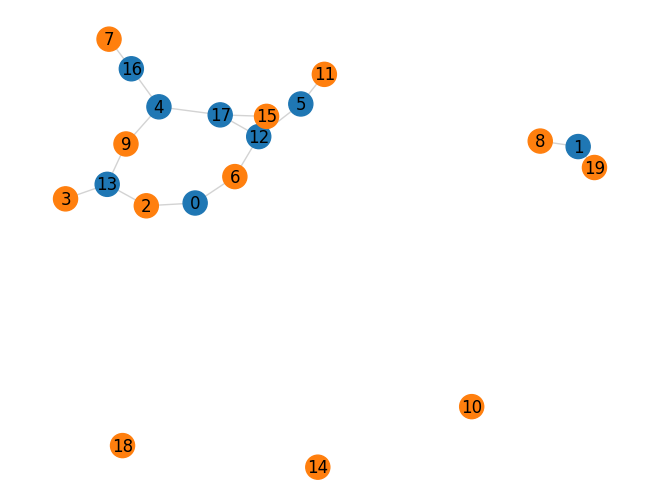

,logit,marginal_p(x=1),independent_set_member
0,-3.846892,0.020900,Not Independent
1,-6.227261,0.001971,Not Independent
2,-0.215651,0.446295,Independent
3,3.740710,0.976813,Independent
4,-3.249315,0.037352,Not Independent
5,-5.531039,0.003946,Not Independent
6,-2.403162,0.082932,Independent
7,3.737771,0.976746,Independent
8,3.831744,0.978788,Independent
9,-0.507857,0.375696,Independent


In [46]:
import pandas as pd
def mis_marginals_dataframe(h_best, p_best):
    n = len(h_best)
    df = pd.DataFrame({
        "logit": h_best,
        "marginal_p(x=1)": p_best,
        "independent_set_member": ["Independent" if x == 1 else "Not Independent" for x in x_best]
    })
    return df

df_mis = mis_marginals_dataframe(h_best, p_best)
draw_graph_with_mis(G, x_best)
df_mis

Example 3

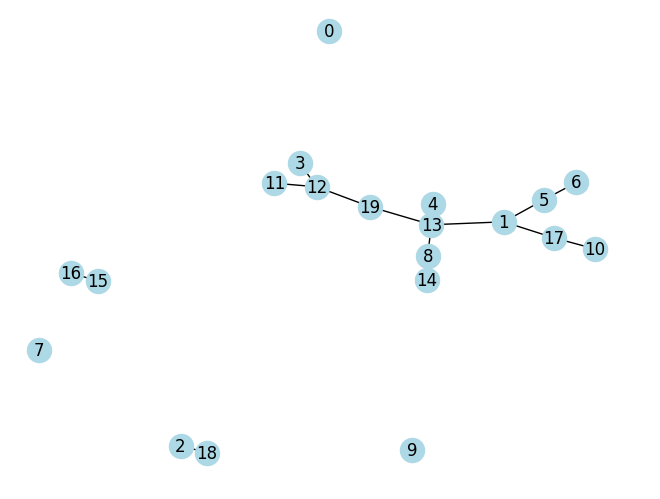

W shape: (20, 20)
Unique values in W: [0. 1.]
Best MIS size: 13
Best logits: [ 5.429216  -1.1174911 -2.0796924  3.8172982  3.7142637 -5.5850673
  3.741739   5.429216  -5.455393   5.429216   3.741739   3.8172982
 -5.991822  -5.2417808  3.72271   -2.0796924 -2.0796924 -5.5850673
 -2.0796924  1.924551 ]
Best marginals: [0.9956326  0.24647693 0.11108633 0.97848594 0.97620654 0.00373946
 0.9768364  0.9956326  0.00425501 0.9956326  0.9768364  0.97848594
 0.00249288 0.00526298 0.9764019  0.11108633 0.11108633 0.00373946
 0.11108633 0.8726451 ]
Best x: [1 1 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1]


In [48]:
n_nodes   = 20
edge_prob = 0.08
seed      = 112

G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
W = graph_to_binary_adjacency(G)
draw_graph(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

out = solve_mis(G, W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)
best_size, h_best, p_best, x_best = out["best_size"], out["h_best"], out["p_best"], out["x_best"]

print("Best MIS size:", best_size)
print("Best logits:", h_best)
print("Best marginals:", p_best)
print("Best x:", x_best)

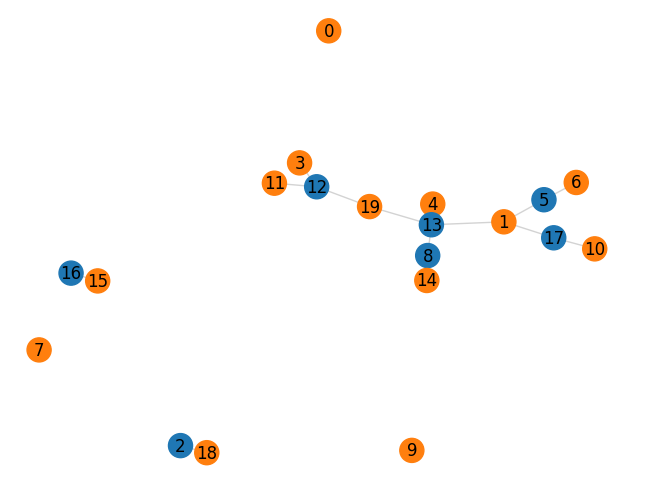

,logit,marginal_p(x=1),independent_set_member
0,5.429216,0.995633,Independent
1,-1.117491,0.246477,Independent
2,-2.079692,0.111086,Not Independent
3,3.817298,0.978486,Independent
4,3.714264,0.976207,Independent
5,-5.585067,0.003739,Not Independent
6,3.741739,0.976836,Independent
7,5.429216,0.995633,Independent
8,-5.455393,0.004255,Not Independent
9,5.429216,0.995633,Independent


In [49]:
import pandas as pd
def mis_marginals_dataframe(h_best, p_best):
    n = len(h_best)
    df = pd.DataFrame({
        "logit": h_best,
        "marginal_p(x=1)": p_best,
        "independent_set_member": ["Independent" if x == 1 else "Not Independent" for x in x_best]
    })
    return df

df_mis = mis_marginals_dataframe(h_best, p_best)
draw_graph_with_mis(G, x_best)
df_mis

Example 4

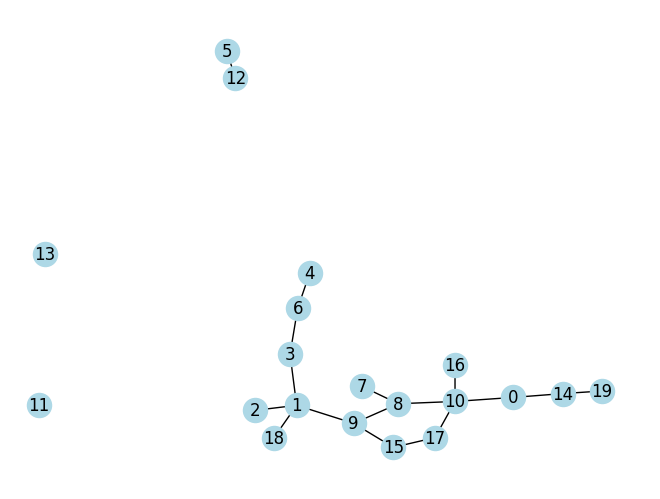

W shape: (20, 20)
Unique values in W: [0. 1.]
Best MIS size: 13
Best logits: [ 1.710939  -5.720945   3.7954814  1.9414363  3.7637503 -2.0796924
 -5.8795834  3.7060463 -5.1298814 -1.9992071 -5.2218604  5.429216
 -2.0796924  5.429216  -5.8375335 -3.6822383  3.7133262 -0.6819416
  3.7954814  3.7612488]
Best marginals: [0.84695804 0.00326591 0.97802174 0.8745099  0.9773293  0.11108633
 0.00278815 0.9760149  0.00588245 0.11928619 0.0053683  0.9956326
 0.11108633 0.9956326  0.00290755 0.02454877 0.9761847  0.3358281
 0.97802174 0.9772739 ]
Best x: [1 0 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1]


In [52]:
n_nodes   = 20
edge_prob = 0.04
seed      = 1

G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
W = graph_to_binary_adjacency(G)
draw_graph(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

out = solve_mis(G, W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)
best_size, h_best, p_best, x_best = out["best_size"], out["h_best"], out["p_best"], out["x_best"]

print("Best MIS size:", best_size)
print("Best logits:", h_best)
print("Best marginals:", p_best)
print("Best x:", x_best)

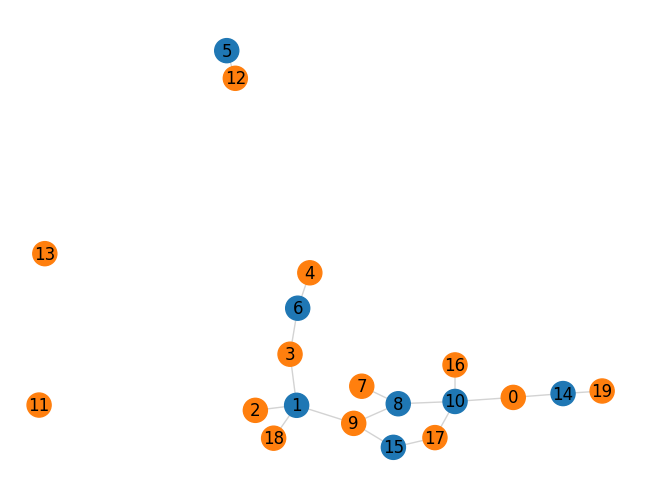

,logit,marginal_p(x=1),independent_set_member
0,1.710939,0.846958,Independent
1,-5.720945,0.003266,Not Independent
2,3.795481,0.978022,Independent
3,1.941436,0.874510,Independent
4,3.763750,0.977329,Independent
5,-2.079692,0.111086,Not Independent
6,-5.879583,0.002788,Not Independent
7,3.706046,0.976015,Independent
8,-5.129881,0.005882,Not Independent
9,-1.999207,0.119286,Independent


In [53]:
import pandas as pd
def mis_marginals_dataframe(h_best, p_best):
    n = len(h_best)
    df = pd.DataFrame({
        "logit": h_best,
        "marginal_p(x=1)": p_best,
        "independent_set_member": ["Independent" if x == 1 else "Not Independent" for x in x_best]
    })
    return df

df_mis = mis_marginals_dataframe(h_best, p_best)
draw_graph_with_mis(G, x_best)
df_mis

Example 5

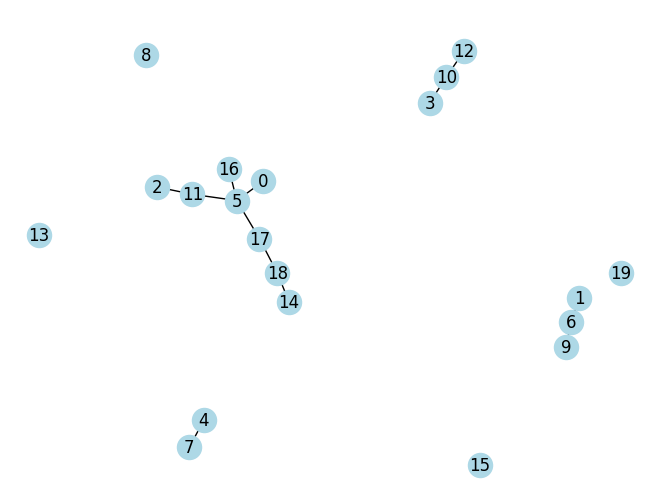

W shape: (20, 20)
Unique values in W: [0. 1.]
Best MIS size: 14
Best logits: [ 3.7936597  3.8317442  3.7165613  3.8317442 -2.0796924 -5.690796
 -6.2272606 -2.0796924  5.429216   3.8317442 -6.2272606 -5.442559
  3.8317442  5.429216   3.7637951  5.429216   3.7936597  1.9387834
 -5.8794127  5.429216 ]
Best marginals: [0.97798264 0.97878796 0.9762598  0.97878796 0.11108633 0.00336554
 0.00197096 0.11108633 0.9956326  0.97878796 0.00197096 0.00430974
 0.97878796 0.9956326  0.9773303  0.9956326  0.97798264 0.8742184
 0.00278863 0.9956326 ]
Best x: [1 1 1 1 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 1]


In [54]:
n_nodes   = 20
edge_prob = 0.05
seed      = 12

G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
W = graph_to_binary_adjacency(G)
draw_graph(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

out = solve_mis(G, W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)
best_size, h_best, p_best, x_best = out["best_size"], out["h_best"], out["p_best"], out["x_best"]

print("Best MIS size:", best_size)
print("Best logits:", h_best)
print("Best marginals:", p_best)
print("Best x:", x_best)

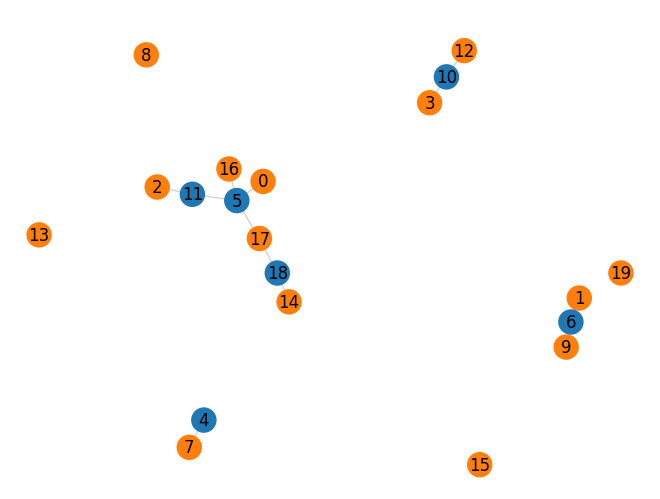

,logit,marginal_p(x=1),independent_set_member
0,3.793660,0.977983,Independent
1,3.831744,0.978788,Independent
2,3.716561,0.976260,Independent
3,3.831744,0.978788,Independent
4,-2.079692,0.111086,Not Independent
5,-5.690796,0.003366,Not Independent
6,-6.227261,0.001971,Not Independent
7,-2.079692,0.111086,Independent
8,5.429216,0.995633,Independent
9,3.831744,0.978788,Independent


In [55]:
import pandas as pd
def mis_marginals_dataframe(h_best, p_best):
    n = len(h_best)
    df = pd.DataFrame({
        "logit": h_best,
        "marginal_p(x=1)": p_best,
        "independent_set_member": ["Independent" if x == 1 else "Not Independent" for x in x_best]
    })
    return df

df_mis = mis_marginals_dataframe(h_best, p_best)
draw_graph_with_mis(G, x_best)
df_mis